# CNN Training — Tubes2 IF3270

Melatih **16 arsitektur Keras CNN** dengan grid search atas 4 hyperparameter:
- Jumlah conv layer: `[2, 4]`
- Banyak filter: `[[32,64], [64,128]]`
- Ukuran filter: `[3, 5]`
- Jenis pooling: `['max', 'avg']`

Dataset: Intel Image Classification (6 kelas, ~25k gambar).
Metrik utama: **macro F1-score**.

In [1]:
import os
import sys
import json
import glob
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as kl
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# Agar bisa import dari src/
sys.path.insert(0, os.path.abspath('../..'))
from src.cnn.utils import load_image, load_batch

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Load Dataset

In [2]:
DATA_DIR = os.path.abspath('../../data/intel')
WEIGHTS_DIR = os.path.abspath('../../data/weights')
HISTORY_DIR = os.path.abspath('../../data/histories')
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

CLASSES = sorted(os.listdir(os.path.join(DATA_DIR, 'train')))
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
print('Classes:', CLASSES)

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 10

def load_split(split):
    """Return (image_paths, labels) for a given split."""
    paths, labels = [], []
    split_dir = os.path.join(DATA_DIR, split)
    for cls in CLASSES:
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for ext in ('*.jpg', '*.jpeg', '*.png'):
            for p in glob.glob(os.path.join(cls_dir, ext)):
                paths.append(p)
                labels.append(CLASS_TO_IDX[cls])
    return paths, np.array(labels)

train_paths, train_labels = load_split('train')
val_paths,   val_labels   = load_split('val')
test_paths,  test_labels  = load_split('test')
print(f'Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}')

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 11230, Val: 2804, Test: 3000


In [3]:
def make_tf_dataset(paths, labels, shuffle=False):
    """Create a tf.data pipeline for efficient loading."""
    h, w = IMG_SIZE

    def load_and_preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [h, w])
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_tf_dataset(train_paths, train_labels, shuffle=True)
val_ds   = make_tf_dataset(val_paths,   val_labels)
test_ds  = make_tf_dataset(test_paths,  test_labels)

## 2. Definisi Fungsi Build Model

In [4]:
def build_model(n_conv, filters_list, kernel_size, pooling_type):
    """
    Bangun model CNN Keras.

    Args:
        n_conv       (int):  Jumlah conv layer (2 atau 4).
        filters_list (list): Filter per layer, misal [32,64] atau [64,128].
                             Jika panjang < n_conv, list di-repeat.
        kernel_size  (int):  Ukuran kernel (3 atau 5).
        pooling_type (str):  'max' atau 'avg'.
    """
    h, w = IMG_SIZE
    inputs = keras.Input(shape=(h, w, 3))
    x = inputs

    # Extend filters_list bila perlu
    filters = [filters_list[i % len(filters_list)] for i in range(n_conv)]

    for i, f in enumerate(filters):
        x = kl.Conv2D(f, kernel_size, activation='relu', padding='same',
                      name=f'conv{i+1}')(x)
        if pooling_type == 'max':
            x = kl.MaxPooling2D(pool_size=(2, 2), name=f'pool{i+1}')(x)
        else:
            x = kl.AveragePooling2D(pool_size=(2, 2), name=f'pool{i+1}')(x)

    x = kl.GlobalAveragePooling2D(name='gap')(x)
    x = kl.Dense(256, activation='relu', name='fc1')(x)
    outputs = kl.Dense(len(CLASSES), activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

## 3. Grid Search — Training 16 Model

In [5]:
from itertools import product

# Hyperparameter grid
N_CONV_OPTIONS     = [2, 4]
FILTERS_OPTIONS    = [[32, 64], [64, 128]]
KERNEL_OPTIONS     = [3, 5]
POOLING_OPTIONS    = ['max', 'avg']

configs = list(product(N_CONV_OPTIONS, FILTERS_OPTIONS, KERNEL_OPTIONS, POOLING_OPTIONS))
print(f'Total konfigurasi: {len(configs)}')

def config_name(n_conv, filters, kernel_size, pooling):
    f_str = '_'.join(map(str, filters))
    return f'cnn_nL{n_conv}_f{f_str}_k{kernel_size}_p{pooling.capitalize()}'

Total konfigurasi: 16


In [ ]:
results = []

for idx, (n_conv, filters, kernel_size, pooling) in enumerate(configs):
    name = config_name(n_conv, filters, kernel_size, pooling)
    weight_path  = os.path.join(WEIGHTS_DIR, f'{name}.keras')
    history_path = os.path.join(HISTORY_DIR, f'{name}.json')

    print(f'\n[{idx+1:02d}/16] {name}')

    # Skip jika sudah dilatih
    if os.path.exists(weight_path) and os.path.exists(history_path):
        print('  → sudah ada, skip.')
        with open(history_path) as f:
            hist = json.load(f)
        results.append({'name': name, 'history': hist})
        continue

    model = build_model(n_conv, filters, kernel_size, pooling)

    callbacks = [
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,
                                       monitor='val_accuracy'),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3,
                                           monitor='val_loss', verbose=1),
    ]

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=1,
    )

    model.save(weight_path)
    hist_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(history_path, 'w') as f:
        json.dump(hist_dict, f)

    results.append({'name': name, 'history': hist_dict})
    print(f'  → disimpan ke {weight_path}')


[01/16] cnn_nL2_f32_64_k3_pMax
  → sudah ada, skip.

[02/16] cnn_nL2_f32_64_k3_pAvg
  → sudah ada, skip.

[03/16] cnn_nL2_f32_64_k5_pMax
  → sudah ada, skip.

[04/16] cnn_nL2_f32_64_k5_pAvg
  → sudah ada, skip.

[05/16] cnn_nL2_f64_128_k3_pMax
  → sudah ada, skip.

[06/16] cnn_nL2_f64_128_k3_pAvg
  → sudah ada, skip.

[07/16] cnn_nL2_f64_128_k5_pMax
  → sudah ada, skip.

[08/16] cnn_nL2_f64_128_k5_pAvg
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 210s 595ms/step - accuracy: 0.4394 - loss: 1.3311 - val_accuracy: 0.5378 - val_loss: 1.1336 - learning_rate: 0.0010
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 212s 604ms/step - accuracy: 0.5535 - loss: 1.0883 - val_accuracy: 0.5863 - val_loss: 1.0271 - learning_rate: 0.0010
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 194s 552ms/step - accuracy: 0.5937 - loss: 1.0071 - val_accuracy: 0.6245 - val_loss: 0.9688 - learning_rate: 0.0010
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 214s 610ms/step - accuracy: 0.6372 - loss: 0.9284 - val_accuracy: 0.6630 - val_loss: 

## 4. Evaluasi — Macro F1-Score pada Val Set

In [ ]:
def evaluate_model(model, ds, labels):
    """Prediksi dan hitung macro F1-score."""
    preds = model.predict(ds, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    f1 = f1_score(labels, pred_labels, average='macro')
    return f1, pred_labels

summary = []
for idx, (n_conv, filters, kernel_size, pooling) in enumerate(configs):
    name = config_name(n_conv, filters, kernel_size, pooling)
    weight_path = os.path.join(WEIGHTS_DIR, f'{name}.keras')
    model = keras.models.load_model(weight_path)
    f1, _ = evaluate_model(model, val_ds, val_labels)
    summary.append({'idx': idx, 'name': name, 'val_f1': f1,
                    'n_conv': n_conv, 'filters': filters,
                    'kernel_size': kernel_size, 'pooling': pooling})
    print(f'{name:45s}  val_macro_F1 = {f1:.4f}')

# Tentukan model terbaik
best = max(summary, key=lambda r: r['val_f1'])
print(f'\nModel terbaik: {best["name"]}  (val_macro_F1 = {best["val_f1"]:.4f})')

# Simpan ringkasan
with open(os.path.join(HISTORY_DIR, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
with open(os.path.join(HISTORY_DIR, 'best_model.json'), 'w') as f:
    json.dump(best, f, indent=2)

cnn_nL2_f32_64_k3_pMax                         val_macro_F1 = 0.8118
cnn_nL2_f32_64_k3_pAvg                         val_macro_F1 = 0.7900
cnn_nL2_f32_64_k5_pMax                         val_macro_F1 = 0.8401
cnn_nL2_f32_64_k5_pAvg                         val_macro_F1 = 0.8151
cnn_nL2_f64_128_k3_pMax                        val_macro_F1 = 0.8147
cnn_nL2_f64_128_k3_pAvg                        val_macro_F1 = 0.8105
cnn_nL2_f64_128_k5_pMax                        val_macro_F1 = 0.8577
cnn_nL2_f64_128_k5_pAvg                        val_macro_F1 = 0.8275
cnn_nL4_f32_64_k3_pMax                         val_macro_F1 = 0.8737
cnn_nL4_f32_64_k3_pAvg                         val_macro_F1 = 0.8586
cnn_nL4_f32_64_k5_pMax                         val_macro_F1 = 0.8795
cnn_nL4_f32_64_k5_pAvg                         val_macro_F1 = 0.8715
cnn_nL4_f64_128_k3_pMax                        val_macro_F1 = 0.8869
cnn_nL4_f64_128_k3_pAvg                        val_macro_F1 = 0.8696
cnn_nL4_f64_128_k5_pMax           

## 5. Plot Ringkasan Training

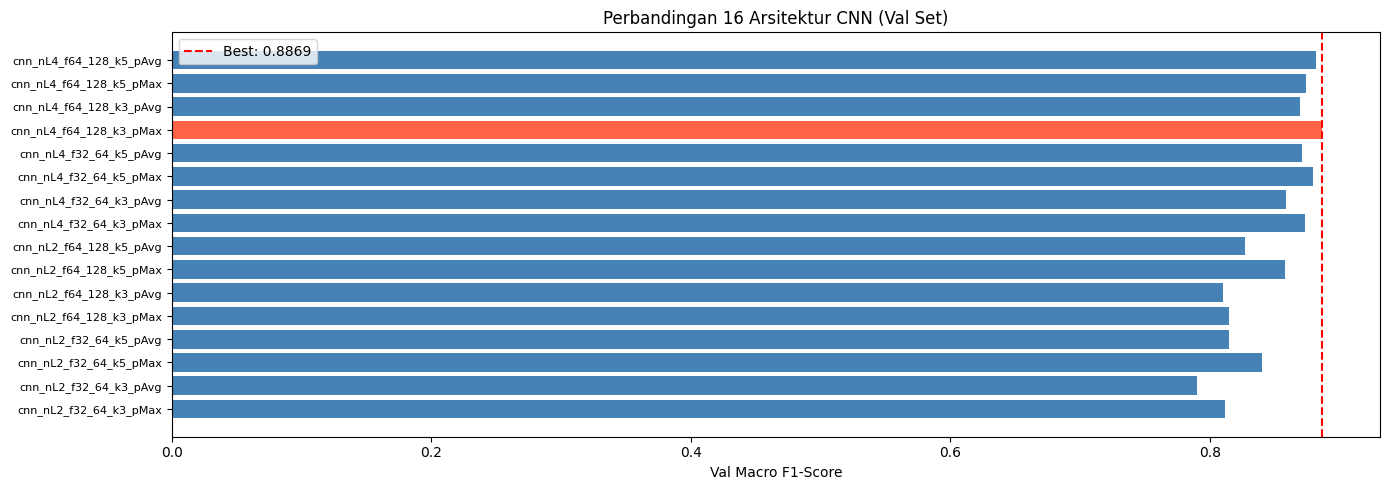

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
names  = [r['name'] for r in summary]
f1s    = [r['val_f1'] for r in summary]
colors = ['steelblue' if r['name'] != best['name'] else 'tomato' for r in summary]

bars = ax.barh(range(len(names)), f1s, color=colors)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel('Val Macro F1-Score')
ax.set_title('Perbandingan 16 Arsitektur CNN (Val Set)')
ax.axvline(best['val_f1'], color='red', linestyle='--', label=f'Best: {best["val_f1"]:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(HISTORY_DIR, 'val_f1_comparison.png'), dpi=150)
plt.show()